# 05 - Modelo XGBoost para densidad de trafico

Objetivo: construir un modelo de Machine Learning con los datos ya disponibles del proyecto para predecir el nivel de densidad/congestion de trafico por distrito, fecha y hora.

Este notebook prioriza una version **defendible en produccion**: las variables usadas por el modelo principal deben conocerse antes de hacer la prediccion. Por defecto se excluyen lags del propio trafico y meteorologia futura, porque pueden no estar disponibles cuando la API reciba solo `fecha`, `hora` y `zona`.

El notebook trabaja sobre `data/processed/tfm_madrid.duckdb`, generado por el pipeline o descargado desde Google Drive con:

```bash
python pipeline/run_pipeline.py --data-source drive
```

La variable objetivo se deriva de `ocupacion_media` cuando existe. Si no existe, se usa `intensidad_media` como alternativa. Los umbrales Bajo/Medio/Alto se calculan solo con train para evitar leakage de la distribucion futura.


## 1. Configuracion e imports

In [18]:
from pathlib import Path
import json
import os
import sys
import warnings

import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError("Instala xgboost o ejecuta el notebook con el .venv del repo.") from exc

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if not (PROJECT_ROOT / "pipeline").exists():
    PROJECT_ROOT = Path("..").resolve()

sys.path.insert(0, str(PROJECT_ROOT))

DB_PATH = PROJECT_ROOT / "data" / "processed" / "tfm_madrid.duckdb"
DATASET_OUT = PROJECT_ROOT / "data" / "processed" / "aforos_dataset_xgboost.csv"
MODEL_OUT = PROJECT_ROOT / "data" / "processed" / "modelo_trafico_xgboost.pkl"
METADATA_OUT = PROJECT_ROOT / "data" / "processed" / "modelo_trafico_xgboost_metadata.json"

RANDOM_STATE = 42
TEST_SIZE_RATIO = 0.20
N_JOBS = max(1, min(4, (os.cpu_count() or 2) - 1))

# Modelo principal production-safe.
# Si se activa meteorologia, la API de produccion debe recibir meteo en vivo o forecast.
# Si se activan lags, el modelo deja de ser prediccion futura pura y pasa a ser nowcasting.
USE_WEATHER_FEATURES = False
USE_LAG_FEATURES = False

print("Proyecto:", PROJECT_ROOT)
print("DuckDB:", DB_PATH)
print("Existe DuckDB:", DB_PATH.exists())
print("N_JOBS:", N_JOBS)
print("USE_WEATHER_FEATURES:", USE_WEATHER_FEATURES)
print("USE_LAG_FEATURES:", USE_LAG_FEATURES)


Proyecto: C:\Users\USUARIO\Desktop\Master\Projects\tfm_codigo
DuckDB: C:\Users\USUARIO\Desktop\Master\Projects\tfm_codigo\data\processed\tfm_madrid.duckdb
Existe DuckDB: True
N_JOBS: 4
USE_WEATHER_FEATURES: False
USE_LAG_FEATURES: False


## 2. Inspeccion de tablas disponibles

In [19]:
import subprocess
import sys


def is_invalid_duckdb(path):
    if not path.exists() or path.stat().st_size == 0:
        return True
    head = path.open("rb").read(256).lstrip().lower()
    return head.startswith(b"<!doctype html") or head.startswith(b"<html")


if is_invalid_duckdb(DB_PATH):
    result = subprocess.run(
        [
            sys.executable,
            "pipeline/run_pipeline.py",
            "--data-source",
            "drive",
            "--force-drive-download",
        ],
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
    )

    print(result.stdout)
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"Fall? la descarga desde Drive con c?digo {result.returncode}")

con = duckdb.connect(str(DB_PATH), read_only=True)
tables = con.execute("SHOW TABLES").df()["name"].tolist()
tables


['aforos_historicos',
 'aforos_por_sensor',
 'equipamientos',
 'equipamientos_por_zona',
 'meteorologia_historica',
 'pipeline_runs']

In [20]:
for table in tables:
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table:30s} {n:>12,d} filas")

aforos_historicos                   457,830 filas
aforos_por_sensor                99,889,690 filas
equipamientos                         1,776 filas
equipamientos_por_zona                   75 filas
meteorologia_historica              432,577 filas
pipeline_runs                             1 filas


## 3. Carga de datos

Usamos siempre el ultimo `run_id` disponible cuando la tabla lo tenga. Asi evitamos mezclar ejecuciones append-only del pipeline.

In [21]:
def table_columns(table_name: str) -> list[str]:
    return con.execute(f"DESCRIBE {table_name}").df()["column_name"].tolist()


def latest_run_id(table_name: str) -> str | None:
    cols = table_columns(table_name)
    if "run_id" not in cols:
        return None
    if "pipeline_runs" in tables:
        row = con.execute(
            f"""
            SELECT p.run_id
            FROM pipeline_runs p
            INNER JOIN (SELECT DISTINCT run_id FROM {table_name}) t USING (run_id)
            ORDER BY p.fecha_ejecucion DESC
            LIMIT 1
            """
        ).fetchone()
        if row:
            return row[0]
    row = con.execute(
        f"""
        SELECT run_id
        FROM {table_name}
        GROUP BY run_id
        ORDER BY run_id DESC
        LIMIT 1
        """
    ).fetchone()
    return row[0] if row else None


def read_latest(table_name: str) -> pd.DataFrame:
    run_id = latest_run_id(table_name)
    if run_id is None:
        return con.execute(f"SELECT * FROM {table_name}").df()
    return con.execute(f"SELECT * FROM {table_name} WHERE run_id = ?", [run_id]).df()


required = "aforos_historicos"
if required not in tables:
    raise ValueError(f"La tabla requerida '{required}' no esta en el DuckDB. Tablas: {tables}")

aforos = read_latest("aforos_historicos")
print(aforos.shape)
aforos.head()

(457830, 6)


,zona,fecha,hora,intensidad_media,ocupacion_media,run_id
0,Arganzuela,2024-01-01,0,185.436747,1.824967,06a4aaf6-1e26-7ec4-8000-748bfea84001
1,Arganzuela,2024-01-01,1,599.749331,5.425368,06a4aaf6-1e26-7ec4-8000-748bfea84001
2,Arganzuela,2024-01-01,2,528.778552,4.949867,06a4aaf6-1e26-7ec4-8000-748bfea84001
3,Arganzuela,2024-01-01,3,298.980254,2.734940,06a4aaf6-1e26-7ec4-8000-748bfea84001
4,Arganzuela,2024-01-01,4,190.947245,1.945565,06a4aaf6-1e26-7ec4-8000-748bfea84001


In [22]:
meteo = read_latest("meteorologia_historica") if "meteorologia_historica" in tables else pd.DataFrame()
equip_zona = read_latest("equipamientos_por_zona") if "equipamientos_por_zona" in tables else pd.DataFrame()

print("Meteorologia:", meteo.shape)
print("Equipamientos por zona:", equip_zona.shape)
display(meteo.head() if len(meteo) else "Sin tabla meteorologia_historica")
display(equip_zona.head() if len(equip_zona) else "Sin tabla equipamientos_por_zona")

Meteorologia: (432577, 6)
Equipamientos por zona: (75, 4)


,fecha,hora,zona,humedad_relativa,temperatura,run_id
0,2024-01-01,0,Arganzuela,78.0,8.1,06a4aaf6-1e26-7ec4-8000-748bfea84001
1,2024-01-01,1,Arganzuela,76.0,8.1,06a4aaf6-1e26-7ec4-8000-748bfea84001
2,2024-01-01,2,Arganzuela,77.0,7.8,06a4aaf6-1e26-7ec4-8000-748bfea84001
3,2024-01-01,3,Arganzuela,78.0,7.3,06a4aaf6-1e26-7ec4-8000-748bfea84001
4,2024-01-01,4,Arganzuela,79.0,6.9,06a4aaf6-1e26-7ec4-8000-748bfea84001


,zona,tipo,n_equipamientos,run_id
0,Arganzuela,centros_educativos,53,06a4aaf6-1e26-7ec4-8000-748bfea84001
1,Arganzuela,centros_mayores,3,06a4aaf6-1e26-7ec4-8000-748bfea84001
2,Arganzuela,hospitales,13,06a4aaf6-1e26-7ec4-8000-748bfea84001
3,Barajas,centros_educativos,24,06a4aaf6-1e26-7ec4-8000-748bfea84001
4,Barajas,centros_mayores,3,06a4aaf6-1e26-7ec4-8000-748bfea84001


## 4. Construccion del dataset production-safe

El dataset se construye separando tres ideas:

1. `target_source`: variable historica observada de trafico usada para crear la etiqueta.
2. `nivel_trafico`: etiqueta Bajo/Medio/Alto, calculada con umbrales aprendidos solo en train.
3. `features`: variables disponibles antes de predecir.

Por defecto, el modelo no usa lags ni meteorologia futura. La meteorologia queda como opcion si el despliegue integra meteo en vivo o forecast.


In [23]:
FESTIVOS_MADRID = {
    "01-01", "06-01", "15-05", "02-05", "25-07", "15-08",
    "12-10", "01-11", "06-12", "08-12", "25-12",
}


def choose_target_source(df: pd.DataFrame) -> str:
    candidates = ["ocupacion_media", "intensidad_media"]
    for col in candidates:
        if col in df.columns and df[col].notna().sum() > 0:
            return col
    raise ValueError(f"No encuentro ninguna columna target entre {candidates}. Columnas: {list(df.columns)}")


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    df["hora"] = df["hora"].astype(int)
    df["dia_semana"] = df["fecha"].dt.dayofweek
    df["mes"] = df["fecha"].dt.month
    df["es_fin_de_semana"] = (df["dia_semana"] >= 5).astype(int)
    df["es_festivo"] = df["fecha"].dt.strftime("%m-%d").isin(FESTIVOS_MADRID).astype(int)
    return df


def fit_target_thresholds(train_df: pd.DataFrame, value_col: str) -> tuple[pd.DataFrame, dict]:
    thresholds = train_df.groupby("zona")[value_col].quantile([0.50, 0.80]).unstack()
    thresholds.columns = ["q50", "q80"]
    global_q50, global_q80 = train_df[value_col].quantile([0.50, 0.80]).tolist()
    global_thresholds = {"q50": float(global_q50), "q80": float(global_q80)}
    return thresholds, global_thresholds


def apply_target_thresholds(
    df: pd.DataFrame,
    thresholds: pd.DataFrame,
    global_thresholds: dict,
    value_col: str,
) -> pd.DataFrame:
    out = df.merge(thresholds, left_on="zona", right_index=True, how="left")
    out["q50"] = out["q50"].fillna(global_thresholds["q50"])
    out["q80"] = out["q80"].fillna(global_thresholds["q80"])
    out["nivel_trafico"] = np.select(
        [out[value_col] <= out["q50"], out[value_col] <= out["q80"]],
        [0, 1],
        default=2,
    ).astype(int)
    return out.drop(columns=["q50", "q80"])


target_source = choose_target_source(aforos)
dataset = aforos.copy()
dataset = dataset.dropna(subset=["zona", "fecha", "hora", target_source])
dataset = add_calendar_features(dataset)

print("Target base:", target_source)
print("Dataset base:", dataset.shape)
dataset[["zona", "fecha", "hora", target_source]].head()


Target base: ocupacion_media
Dataset base: (457830, 10)


,zona,fecha,hora,ocupacion_media
0,Arganzuela,2024-01-01,0,1.824967
1,Arganzuela,2024-01-01,1,5.425368
2,Arganzuela,2024-01-01,2,4.949867
3,Arganzuela,2024-01-01,3,2.734940
4,Arganzuela,2024-01-01,4,1.945565


In [24]:
if USE_WEATHER_FEATURES and len(meteo):
    meteo_model = meteo.copy()
    meteo_model["fecha"] = pd.to_datetime(meteo_model["fecha"])
    keep_cols = [c for c in ["zona", "fecha", "hora", "temperatura", "humedad_relativa"] if c in meteo_model.columns]
    dataset = dataset.merge(meteo_model[keep_cols], on=["zona", "fecha", "hora"], how="left")
elif len(meteo):
    print("Meteorologia historica disponible, pero excluida del modelo principal para evitar dependencia de forecast/meteo futura.")

if len(equip_zona):
    equip_pivot = (
        equip_zona.pivot_table(index="zona", columns="tipo", values="n_equipamientos", aggfunc="sum", fill_value=0)
        .add_prefix("n_")
        .reset_index()
    )
    dataset = dataset.merge(equip_pivot, on="zona", how="left")
else:
    equip_pivot = pd.DataFrame()

dataset = dataset.sort_values(["zona", "fecha", "hora"]).reset_index(drop=True)
dataset.head()


Meteorologia historica disponible, pero excluida del modelo principal para evitar dependencia de forecast/meteo futura.


,zona,fecha,hora,intensidad_media,ocupacion_media,run_id,dia_semana,mes,es_fin_de_semana,es_festivo,n_bomberos,n_centros_educativos,n_centros_mayores,n_hospitales
0,Arganzuela,2024-01-01,0,185.436747,1.824967,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
1,Arganzuela,2024-01-01,1,599.749331,5.425368,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
2,Arganzuela,2024-01-01,2,528.778552,4.949867,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
3,Arganzuela,2024-01-01,3,298.980254,2.734940,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
4,Arganzuela,2024-01-01,4,190.947245,1.945565,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13


In [25]:
if USE_LAG_FEATURES:
    print("Aviso: los lags solo son defendibles si produccion dispone de trafico observado reciente.")
    for lag in [1, 24, 168]:
        dataset[f"{target_source}_lag_{lag}h"] = dataset.groupby("zona")[target_source].shift(lag)
    dataset[f"{target_source}_rolling_24h"] = dataset.groupby("zona")[target_source].transform(
        lambda s: s.shift(1).rolling(window=24, min_periods=3).mean()
    )
else:
    print("Lags desactivados: modelo principal compatible con prediccion por fecha/hora/zona.")

print("Dataset con features candidatas:", dataset.shape)
dataset.head()


Lags desactivados: modelo principal compatible con prediccion por fecha/hora/zona.
Dataset con features candidatas: (457830, 14)


,zona,fecha,hora,intensidad_media,ocupacion_media,run_id,dia_semana,mes,es_fin_de_semana,es_festivo,n_bomberos,n_centros_educativos,n_centros_mayores,n_hospitales
0,Arganzuela,2024-01-01,0,185.436747,1.824967,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
1,Arganzuela,2024-01-01,1,599.749331,5.425368,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
2,Arganzuela,2024-01-01,2,528.778552,4.949867,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
3,Arganzuela,2024-01-01,3,298.980254,2.734940,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13
4,Arganzuela,2024-01-01,4,190.947245,1.945565,06a4aaf6-1e26-7ec4-8000-748bfea84001,0,1,0,1,0,53,3,13


## 5. Split temporal y target sin leakage

Primero se separa train/test por fecha. Despues se calculan los umbrales Bajo/Medio/Alto solo con train y se aplican a train y test. Asi el test no influye en la definicion del target.


In [26]:
unique_dates = np.array(sorted(dataset["fecha"].dt.date.unique()))
cut_idx = int(len(unique_dates) * (1 - TEST_SIZE_RATIO))
cutoff_date = unique_dates[cut_idx]

train_raw = dataset[dataset["fecha"].dt.date < cutoff_date].copy()
test_raw = dataset[dataset["fecha"].dt.date >= cutoff_date].copy()

target_thresholds, global_target_thresholds = fit_target_thresholds(train_raw, target_source)
train_df = apply_target_thresholds(train_raw, target_thresholds, global_target_thresholds, target_source)
test_df = apply_target_thresholds(test_raw, target_thresholds, global_target_thresholds, target_source)
dataset = pd.concat([train_df, test_df], ignore_index=True)

DATASET_OUT.parent.mkdir(parents=True, exist_ok=True)
dataset.to_csv(DATASET_OUT, index=False)

print("Fecha corte:", cutoff_date)
print("Train:", train_df.shape, train_df["fecha"].min(), train_df["fecha"].max())
print("Test:", test_df.shape, test_df["fecha"].min(), test_df["fecha"].max())
print("Umbrales globales aprendidos en train:", global_target_thresholds)
print("Guardado en:", DATASET_OUT)

label_names = {0: "Bajo", 1: "Medio", 2: "Alto"}
display(dataset["nivel_trafico"].value_counts(normalize=True).sort_index().rename(index=label_names))
display(train_df["nivel_trafico"].value_counts(normalize=True).sort_index().rename(index=label_names).to_frame("train"))
display(test_df["nivel_trafico"].value_counts(normalize=True).sort_index().rename(index=label_names).to_frame("test"))


Fecha corte: 2025-12-30
Train: (366226, 15) 2024-01-01 00:00:00 2025-12-29 00:00:00
Test: (91604, 15) 2025-12-30 00:00:00 2026-06-30 00:00:00
Umbrales globales aprendidos en train: {'q50': 4.8972273235388055, 'q80': 8.641768292682928}
Guardado en: C:\Users\USUARIO\Desktop\Master\Projects\tfm_codigo\data\processed\aforos_dataset_xgboost.csv


nivel_trafico
Bajo     0.501376
Medio    0.296855
Alto     0.201769
Name: proportion, dtype: float64

,train
nivel_trafico,
Bajo,0.500041
Medio,0.299962
Alto,0.199997


,test
nivel_trafico,
Bajo,0.506714
Medio,0.284431
Alto,0.208856


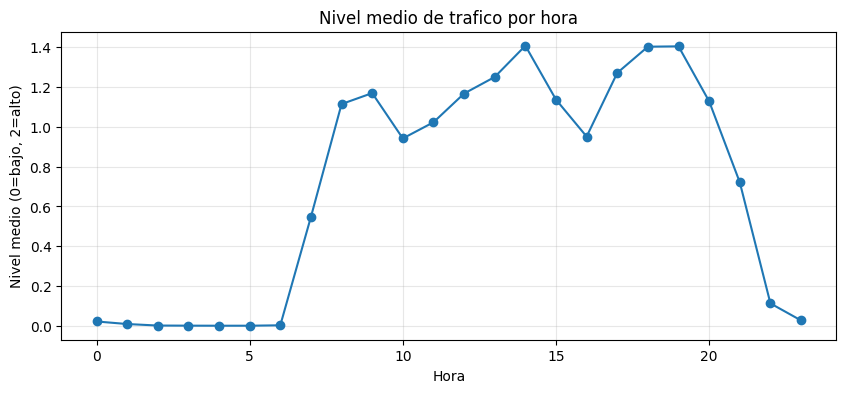

In [27]:
pivot_hora = dataset.groupby("hora")["nivel_trafico"].mean()
pivot_hora.plot(marker="o", figsize=(10, 4))
plt.title("Nivel medio de trafico por hora")
plt.ylabel("Nivel medio (0=bajo, 2=alto)")
plt.xlabel("Hora")
plt.grid(alpha=0.3)
plt.show()


## 6. Variables del modelo

Se excluyen explicitamente las columnas observadas de trafico usadas para crear el target. Los nulos de features se imputan usando solo medianas aprendidas en train.


In [28]:
drop_cols = {
    "fecha", "run_id", "nivel_trafico", target_source,
    "intensidad_media", "ocupacion_media", "carga_media",
}
feature_cols = [c for c in dataset.columns if c not in drop_cols]

leaky_feature_tokens = ["intensidad_media", "ocupacion_media", "carga_media"]
leaky_features = [c for c in feature_cols if any(token in c for token in leaky_feature_tokens)]
if leaky_features:
    raise ValueError(f"Features con posible leakage detectadas: {leaky_features}")

if not USE_LAG_FEATURES:
    lag_features = [c for c in feature_cols if "lag_" in c or "rolling" in c]
    if lag_features:
        raise ValueError(f"Hay lags en feature_cols aunque USE_LAG_FEATURES=False: {lag_features}")

categorical_features = [c for c in ["zona"] if c in feature_cols]
numeric_features = [c for c in feature_cols if c not in categorical_features]

feature_medians = train_df[numeric_features].median(numeric_only=True).to_dict() if numeric_features else {}
for col in numeric_features:
    fill_value = feature_medians.get(col, 0.0)
    train_df[col] = train_df[col].fillna(fill_value)
    test_df[col] = test_df[col].fillna(fill_value)
    dataset[col] = dataset[col].fillna(fill_value)

X_train = train_df[feature_cols]
y_train = train_df["nivel_trafico"]
X_test = test_df[feature_cols]
y_test = test_df["nivel_trafico"]

# Ventana de validacion interna para XGBoost early stopping.
# El test final queda completamente reservado para la evaluacion final.
train_dates = np.array(sorted(train_df["fecha"].dt.date.unique()))
valid_cut_idx = max(1, int(len(train_dates) * 0.80))
valid_cutoff_date = train_dates[min(valid_cut_idx, len(train_dates) - 1)]
fit_df = train_df[train_df["fecha"].dt.date < valid_cutoff_date].copy()
valid_df = train_df[train_df["fecha"].dt.date >= valid_cutoff_date].copy()

X_fit = fit_df[feature_cols]
y_fit = fit_df["nivel_trafico"]
X_valid = valid_df[feature_cols]
y_valid = valid_df["nivel_trafico"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

print("Features categoricas:", categorical_features)
print("Features numericas:", numeric_features)
print("Features finales:", feature_cols)
print("Train completo:", X_train.shape)
print("Train fit:", X_fit.shape, "Validacion early stopping:", X_valid.shape)
print("Fecha corte validacion interna:", valid_cutoff_date)


Features categoricas: ['zona']
Features numericas: ['hora', 'dia_semana', 'mes', 'es_fin_de_semana', 'es_festivo', 'n_bomberos', 'n_centros_educativos', 'n_centros_mayores', 'n_hospitales']
Features finales: ['zona', 'hora', 'dia_semana', 'mes', 'es_fin_de_semana', 'es_festivo', 'n_bomberos', 'n_centros_educativos', 'n_centros_mayores', 'n_hospitales']
Train completo: (366226, 10)
Train fit: (292803, 10) Validacion early stopping: (73423, 10)
Fecha corte validacion interna: 2025-08-06


## 7. Entrenamiento de modelos con busqueda de hiperparametros

La busqueda se mantiene deliberadamente compacta para que sea ejecutable en un equipo local con 16 GB de RAM. Se evita paralelismo anidado: `GridSearchCV` paraleliza por candidatos y cada Random Forest individual usa un solo hilo.


In [29]:
def model_metrics(model, X_tr, y_tr, X_te, y_te) -> dict:
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    train_f1 = f1_score(y_tr, pred_train, average="macro")
    test_f1 = f1_score(y_te, pred_test, average="macro")
    return {
        "train_accuracy": accuracy_score(y_tr, pred_train),
        "test_accuracy": accuracy_score(y_te, pred_test),
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1,
        "gap_f1_train_test": train_f1 - test_f1,
    }


cv = TimeSeriesSplit(n_splits=3)
results = []
trained = {}

search_spaces = {
    "dummy": {
        "estimator": DummyClassifier(random_state=RANDOM_STATE),
        "param_grid": {
            "model__strategy": ["most_frequent", "stratified", "prior"],
        },
    },
    "random_forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [10, 16],
            "model__min_samples_leaf": [5, 10],
            "model__max_features": ["sqrt"],
        },
    },
}

for name, cfg in search_spaces.items():
    print(f"Entrenando {name}...")
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", cfg["estimator"])])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=cfg["param_grid"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=N_JOBS,
        refit=True,
        verbose=1,
    )
    grid.fit(X_train, y_train)
    best_pipe = grid.best_estimator_
    trained[name] = best_pipe
    row = {
        "modelo": name,
        "cv_f1_macro": grid.best_score_,
        "best_params": grid.best_params_,
        "early_stopping_best_trees": None,
    }
    row.update(model_metrics(best_pipe, X_train, y_train, X_test, y_test))
    results.append(row)

# XGBoost: grid search manual + early stopping en validacion temporal interna.
xgb_param_grid = list(ParameterGrid({
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.10],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 5],
    "reg_lambda": [1.0],
}))

xgb_pre_es = clone(preprocessor)
X_fit_es = xgb_pre_es.fit_transform(X_fit)
X_valid_es = xgb_pre_es.transform(X_valid)

best_xgb_score = -np.inf
best_xgb_params = None
best_xgb_trees = None
xgb_search_rows = []

for i, params in enumerate(xgb_param_grid, 1):
    print(f"XGBoost {i}/{len(xgb_param_grid)}: {params}")
    xgb_es = XGBClassifier(
        n_estimators=600,
        objective="multi:softprob",
        eval_metric="mlogloss",
        early_stopping_rounds=30,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        tree_method="hist",
        **params,
    )
    xgb_es.fit(X_fit_es, y_fit, eval_set=[(X_valid_es, y_valid)], verbose=False)
    valid_pred = xgb_es.predict(X_valid_es)
    valid_f1 = f1_score(y_valid, valid_pred, average="macro")
    best_iteration = getattr(xgb_es, "best_iteration", None)
    n_trees = int(best_iteration + 1) if best_iteration is not None else int(xgb_es.n_estimators)
    xgb_search_rows.append({**params, "valid_f1_macro": valid_f1, "best_trees": n_trees})
    if valid_f1 > best_xgb_score:
        best_xgb_score = valid_f1
        best_xgb_params = params
        best_xgb_trees = n_trees

xgb_search_df = pd.DataFrame(xgb_search_rows).sort_values("valid_f1_macro", ascending=False)
display(xgb_search_df.head(10))

xgb_final = XGBClassifier(
    n_estimators=best_xgb_trees,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    tree_method="hist",
    **best_xgb_params,
)
xgb_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", xgb_final)])
xgb_pipe.fit(X_train, y_train)
trained["xgboost"] = xgb_pipe

row = {
    "modelo": "xgboost",
    "cv_f1_macro": best_xgb_score,
    "best_params": best_xgb_params,
    "early_stopping_best_trees": best_xgb_trees,
}
row.update(model_metrics(xgb_pipe, X_train, y_train, X_test, y_test))
results.append(row)

results_df = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False)
results_df

Entrenando dummy...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Entrenando random_forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost 1/8: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost 2/8: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost 3/8: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost 4/8: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost 5/8: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost 6/8: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost

,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,valid_f1_macro,best_trees
2,0.8,0.05,5,1,1.0,0.8,0.819058,392
7,0.8,0.10,5,5,1.0,0.8,0.818882,250
3,0.8,0.05,5,5,1.0,0.8,0.818859,353
6,0.8,0.10,5,1,1.0,0.8,0.817725,222
5,0.8,0.10,3,5,1.0,0.8,0.815610,600
1,0.8,0.05,3,5,1.0,0.8,0.815390,600
0,0.8,0.05,3,1,1.0,0.8,0.814940,600
4,0.8,0.10,3,1,1.0,0.8,0.814740,510


,modelo,cv_f1_macro,best_params,early_stopping_best_trees,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro,gap_f1_train_test
2,xgboost,0.819058,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",392.0,0.869204,0.809430,0.847499,0.784592,0.062907
1,random_forest,0.802670,"{'model__max_depth': 16, 'model__max_features'...",NaN,0.849145,0.780162,0.827826,0.754169,0.073658
0,dummy,0.333933,{'model__strategy': 'stratified'},NaN,0.380555,0.381752,0.333708,0.334353,-0.000645


## 8. Evaluacion del modelo ganador

Mejor modelo: xgboost

Metricas train:
              precision    recall  f1-score   support

        Bajo       0.96      0.92      0.94    183128
       Medio       0.78      0.82      0.80    109854
        Alto       0.79      0.81      0.80     73244

    accuracy                           0.87    366226
   macro avg       0.84      0.85      0.85    366226
weighted avg       0.87      0.87      0.87    366226


Metricas test:
              precision    recall  f1-score   support

        Bajo       0.96      0.85      0.90     46417
       Medio       0.67      0.77      0.72     26055
        Alto       0.70      0.77      0.73     19132

    accuracy                           0.81     91604
   macro avg       0.78      0.80      0.78     91604
weighted avg       0.83      0.81      0.81     91604



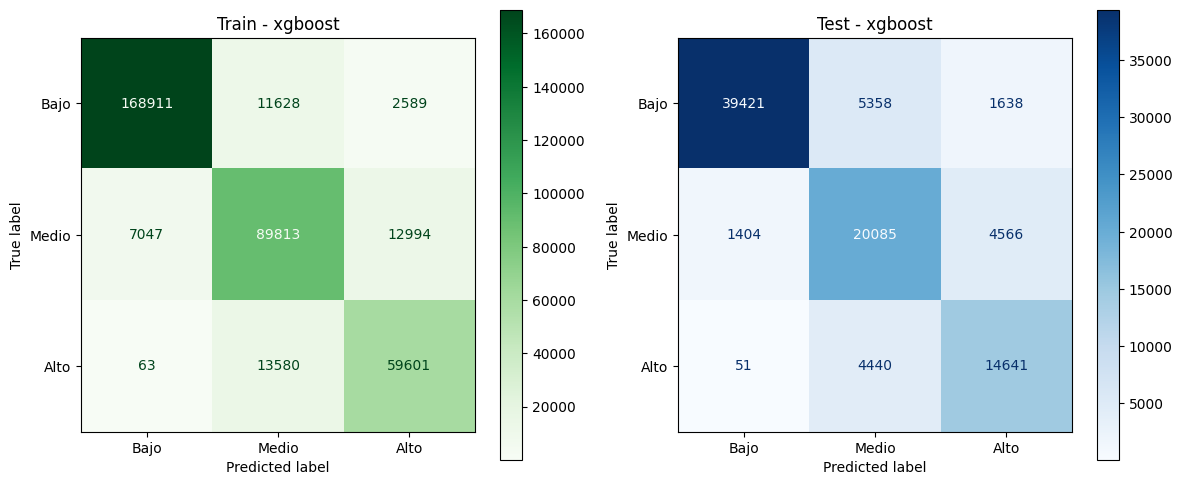

In [30]:
best_name = results_df.iloc[0]["modelo"]
best_model = trained[best_name]
y_train_pred = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

print("Mejor modelo:", best_name)
print("\nMetricas train:")
print(classification_report(y_train, y_train_pred, target_names=["Bajo", "Medio", "Alto"]))
print("\nMetricas test:")
print(classification_report(y_test, y_pred, target_names=["Bajo", "Medio", "Alto"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    display_labels=["Bajo", "Medio", "Alto"],
    cmap="Greens",
    values_format="d",
    ax=axes[0],
)
axes[0].set_title(f"Train - {best_name}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Bajo", "Medio", "Alto"],
    cmap="Blues",
    values_format="d",
    ax=axes[1],
)
axes[1].set_title(f"Test - {best_name}")
plt.tight_layout()
plt.show()

,hora,accuracy_por_hora
0,0,0.974797
1,1,0.992912
2,2,0.998695
3,3,0.999478
4,4,0.999475


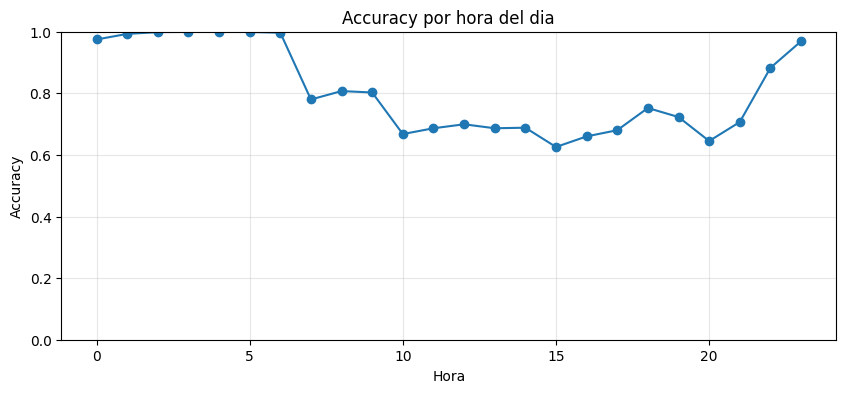

In [31]:
errors = test_df.copy()
errors["pred"] = y_pred
errors["acierto"] = errors["nivel_trafico"] == errors["pred"]

display(errors.groupby("hora")["acierto"].mean().rename("accuracy_por_hora").reset_index().head())

errors.groupby("hora")["acierto"].mean().plot(figsize=(10, 4), marker="o")
plt.ylim(0, 1)
plt.title("Accuracy por hora del dia")
plt.xlabel("Hora")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.show()

## 9. Importancia de variables y SHAP values

Primero mostramos la importancia nativa de XGBoost si se ha entrenado. Despues calculamos SHAP values para el modelo ganador cuando sea un modelo de arboles compatible (`xgboost` o `random_forest`).

,feature,importance
21,num__hora,0.295500
24,num__es_fin_de_semana,0.225870
22,num__dia_semana,0.092850
23,num__mes,0.063739
3,cat__zona_Centro,0.035253
11,cat__zona_Moratalaz,0.029833
28,num__n_centros_mayores,0.027022
26,num__n_bomberos,0.022391
29,num__n_hospitales,0.020291
5,cat__zona_Chamberi,0.017734


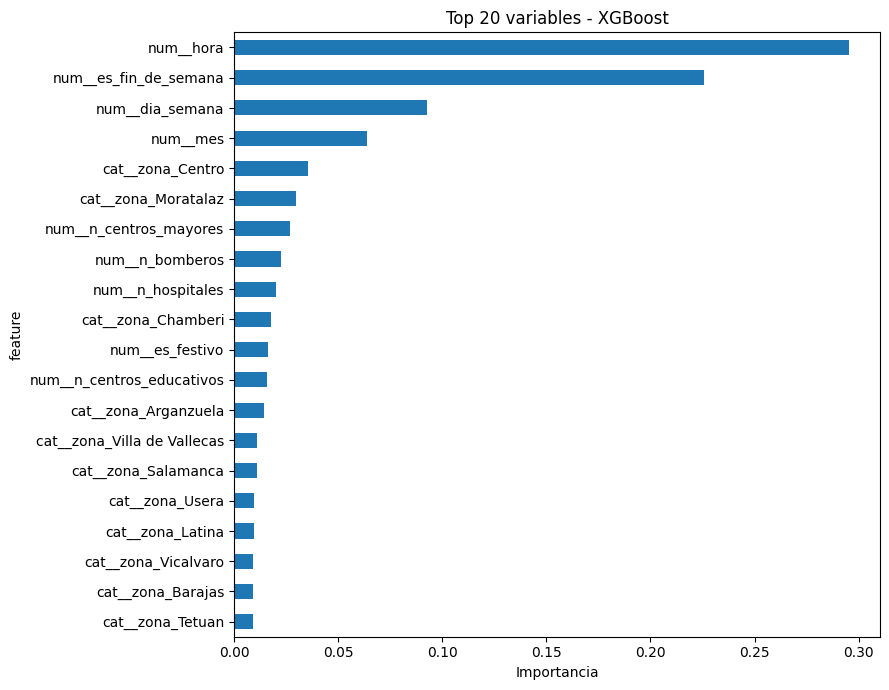

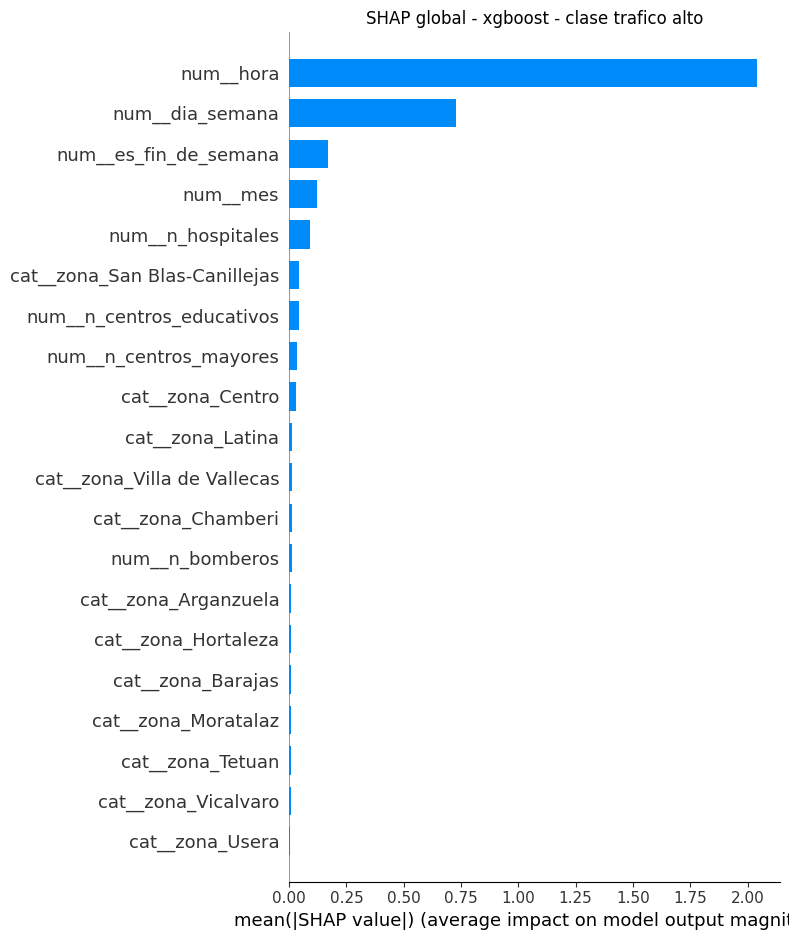

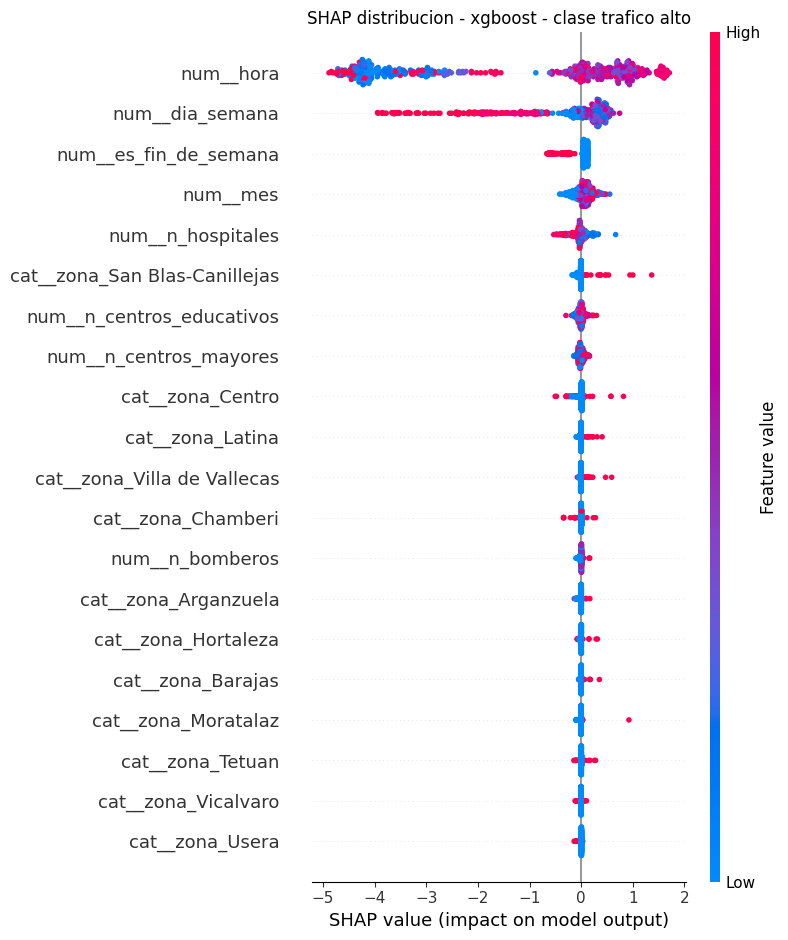

In [32]:
xgb_pipe = trained.get("xgboost")
if xgb_pipe is not None:
    pre = xgb_pipe.named_steps["preprocessor"]
    xgb = xgb_pipe.named_steps["model"]
    feature_names = pre.get_feature_names_out()
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": xgb.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(importances.head(20))
    importances.head(20).iloc[::-1].plot(kind="barh", x="feature", y="importance", legend=False, figsize=(9, 7))
    plt.title("Top 20 variables - XGBoost")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

try:
    import shap
    import xgboost as xgb_native
except ImportError as exc:
    raise ImportError(
        "Para calcular SHAP values instala shap y xgboost en el entorno. "
        "Tambien puedes a?adirlos a requirements.txt y reinstalar dependencias."
    ) from exc

if best_name not in {"xgboost", "random_forest"}:
    raise ValueError(f"SHAP TreeExplainer no aplica al modelo ganador '{best_name}'.")

sample_size = min(500, len(X_test))
X_shap_raw = X_test.sample(sample_size, random_state=RANDOM_STATE)
pre = best_model.named_steps["preprocessor"]
tree_model = best_model.named_steps["model"]
feature_names = pre.get_feature_names_out()
X_shap = pre.transform(X_shap_raw)
if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# En multiclase, representamos la clase 2 = trafico alto.
class_for_plot = 2

if best_name == "xgboost":
    # SHAP TreeExplainer puede fallar con XGBoost >= 3 en multiclase por el base_score vectorial.
    # Usamos las contribuciones SHAP nativas de XGBoost, equivalentes para modelos de arboles.
    booster = tree_model.get_booster()
    dmatrix = xgb_native.DMatrix(X_shap_df, feature_names=list(feature_names))
    contribs = booster.predict(dmatrix, pred_contribs=True)

    if contribs.ndim == 3 and contribs.shape[2] == len(feature_names) + 1:
        class_idx = min(class_for_plot, contribs.shape[1] - 1)
        shap_for_plot = contribs[:, class_idx, :-1]
    elif contribs.ndim == 3 and contribs.shape[1] == len(feature_names) + 1:
        class_idx = min(class_for_plot, contribs.shape[2] - 1)
        shap_for_plot = contribs[:, :-1, class_idx]
    elif contribs.ndim == 2:
        shap_for_plot = contribs[:, :-1]
    else:
        raise ValueError(f"Forma inesperada de pred_contribs: {contribs.shape}")
else:
    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(X_shap_df)
    if isinstance(shap_values, list):
        class_idx = min(class_for_plot, len(shap_values) - 1)
        shap_for_plot = shap_values[class_idx]
    elif getattr(shap_values, "ndim", 0) == 3:
        class_idx = min(class_for_plot, shap_values.shape[2] - 1)
        shap_for_plot = shap_values[:, :, class_idx]
    else:
        shap_for_plot = shap_values

shap.summary_plot(shap_for_plot, X_shap_df, plot_type="bar", show=False)
plt.title(f"SHAP global - {best_name} - clase trafico alto")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_for_plot, X_shap_df, show=False)
plt.title(f"SHAP distribucion - {best_name} - clase trafico alto")
plt.tight_layout()
plt.show()


## 10. Guardado de artefactos

In [33]:
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_OUT)

target_thresholds_for_json = (
    target_thresholds.reset_index().assign(q50=lambda d: d["q50"].astype(float), q80=lambda d: d["q80"].astype(float))
    .to_dict(orient="records")
)

metadata = {
    "best_model": best_name,
    "target": "nivel_trafico",
    "target_source": target_source,
    "feature_cols": feature_cols,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "feature_medians_train": {k: float(v) for k, v in feature_medians.items()},
    "use_weather_features": USE_WEATHER_FEATURES,
    "use_lag_features": USE_LAG_FEATURES,
    "test_size_ratio": TEST_SIZE_RATIO,
    "cutoff_date": str(cutoff_date),
    "target_thresholds_global_train": global_target_thresholds,
    "target_thresholds_by_zone_train": target_thresholds_for_json,
    "metrics": results_df.to_dict(orient="records"),
    "xgboost_grid_search_top": xgb_search_df.head(20).to_dict(orient="records") if "xgb_search_df" in globals() else [],
    "labels": {"0": "Bajo", "1": "Medio", "2": "Alto"},
}

with METADATA_OUT.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Modelo guardado:", MODEL_OUT)
print("Metadata guardada:", METADATA_OUT)


Modelo guardado: C:\Users\USUARIO\Desktop\Master\Projects\tfm_codigo\data\processed\modelo_trafico_xgboost.pkl
Metadata guardada: C:\Users\USUARIO\Desktop\Master\Projects\tfm_codigo\data\processed\modelo_trafico_xgboost_metadata.json


## 11. Funcion de prediccion production-safe

Esta funcion genera una fila por zona usando solo variables disponibles antes de la prediccion. Si se activan variables de meteorologia, se debe pasar un `meteo_actual` con `zona`, `temperatura` y `humedad_relativa`. Si se activan lags, esta funcion falla a proposito porque haria falta definir una fuente operacional de trafico observado reciente.


In [34]:
def crear_features_produccion(fecha: str, hora: int, zonas=None, meteo_actual: pd.DataFrame | None = None) -> pd.DataFrame:
    if any("lag_" in c or "rolling" in c for c in feature_cols):
        raise ValueError(
            "El modelo usa lags de trafico. Para prediccion real hay que conectar una fuente de trafico observado reciente."
        )

    if zonas is None:
        zonas = sorted(dataset["zona"].dropna().unique())

    rows = pd.DataFrame({"zona": zonas})
    rows["fecha"] = pd.to_datetime(fecha)
    rows["hora"] = int(hora)
    rows = add_calendar_features(rows)

    if len(equip_pivot):
        rows = rows.merge(equip_pivot, on="zona", how="left")

    if USE_WEATHER_FEATURES:
        if meteo_actual is None:
            raise ValueError(
                "El modelo usa meteorologia. Pasa meteo_actual con columnas zona, temperatura y humedad_relativa."
            )
        meteo_req = ["zona", "temperatura", "humedad_relativa"]
        missing = [c for c in meteo_req if c not in meteo_actual.columns]
        if missing:
            raise ValueError(f"Faltan columnas en meteo_actual: {missing}")
        rows = rows.merge(meteo_actual[meteo_req], on="zona", how="left")

    for col in feature_cols:
        if col not in rows.columns:
            rows[col] = 0

    for col in numeric_features:
        rows[col] = pd.to_numeric(rows[col], errors="coerce").fillna(feature_medians.get(col, 0.0))

    return rows[feature_cols]


def predecir_trafico(fecha: str, hora: int, modelo=best_model, zonas=None, meteo_actual: pd.DataFrame | None = None) -> pd.DataFrame:
    X_pred = crear_features_produccion(fecha, hora, zonas=zonas, meteo_actual=meteo_actual)
    pred = modelo.predict(X_pred)
    out = pd.DataFrame({
        "zona": X_pred["zona"].values if "zona" in X_pred.columns else zonas,
        "fecha": pd.to_datetime(fecha),
        "hora": int(hora),
        "pred": pred,
    })
    out["pred_label"] = out["pred"].map(label_names)
    return out.sort_values("zona")


sample_fecha = str(test_df["fecha"].dt.date.iloc[0])
sample_hora = int(test_df["hora"].iloc[0])
predecir_trafico(sample_fecha, sample_hora).head(10)


,zona,fecha,hora,pred,pred_label
0,Arganzuela,2025-12-30,0,0,Bajo
1,Barajas,2025-12-30,0,0,Bajo
2,Carabanchel,2025-12-30,0,0,Bajo
3,Centro,2025-12-30,0,0,Bajo
4,Chamartin,2025-12-30,0,0,Bajo
5,Chamberi,2025-12-30,0,0,Bajo
6,Ciudad Lineal,2025-12-30,0,0,Bajo
7,Fuencarral-El Pardo,2025-12-30,0,0,Bajo
8,Hortaleza,2025-12-30,0,0,Bajo
9,Latina,2025-12-30,0,0,Bajo


## 12. Conclusiones para la memoria

- Se ha construido un dataset real desde los artefactos del pipeline, sin datos sinteticos.
- El objetivo se define como clasificacion ordinal de congestion: bajo, medio y alto.
- La validacion es temporal, por lo que mide capacidad de generalizacion hacia fechas posteriores.
- Los umbrales del target se aprenden solo con train para evitar leakage de la distribucion futura.
- El modelo principal usa variables disponibles antes de la prediccion: zona, calendario y equipamientos estaticos.
- La meteorologia y los lags quedan como extensiones condicionadas a que produccion aporte meteo en vivo/forecast o trafico observado reciente.
- XGBoost se compara contra un baseline y Random Forest con el mismo protocolo.
- El modelo guardado puede integrarse en `ml/predict.py` usando la funcion `predecir_trafico` como referencia.
